# Workflow Demonstration

In [1]:
import superstats as sup
import numpy as np

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/lschumacher/.local/share/uv/python/cpython-3.13.14-macos-aarch64-none/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
INFO:bayesflow:Using backend 'jax'


## Simulator

The first part of the notebook demonstrates how to define different types of parameters (e.g., stochastic / deterministic time-varying) and connect them to an observation model.

### Constants

`NUM_STEPS` is the number of ordered trials in each simulated dataset. Set it to the length of the empirical sequences you plan to analyze, or use a common window length if sequences differ. Longer sequences can reveal slower changes in the latent parameters, but they also increase simulation, training, and memory costs.

In [2]:
NUM_STEPS = 100

### Specifying an Observation Model

In this demonstration, the observation model is the Diffusion Decision Model (DDM), which is already implemented in `superstats`. The DDM describes a binary decision as noisy evidence accumulation. To distinguish trials from within-trial diffusion time, let $t$ index trials and let $s$ denote elapsed time during trial $t$. The latent evidence process follows the stochastic differential equation

$$
dX_t(s) = v_t \, ds + \sigma \, dW_t(s), \qquad X_t(0) = z_t a_t.
$$

Here, $W_t(s)$ is a standard Wiener process and $\sigma$ controls within-trial diffusion noise. The evidence starts between an absorbing lower boundary at $0$ and upper boundary at $a_t$. The decision time is the first-passage time, written as the infimum

$$
\operatorname{DT}_t = \inf \left\{s \geq 0 : X_t(s) \notin (0, a_t)\right\}.
$$

The infimum selects the earliest time at which the evidence reaches either threshold. The observed choice records which boundary was reached:

$$
Y_t = \begin{cases}
1, & X_t(\operatorname{DT}_t) \geq a_t, \\
0, & X_t(\operatorname{DT}_t) \leq 0.
\end{cases}
$$

Finally, the observed response time is the decision time plus non-decision time (NDT):

$$
\operatorname{RT}_t = \operatorname{DT}_t + \tau_t.
$$

The model parameters therefore have the following interpretations:

- $v_t$ (drift rate): the average speed and direction of evidence accumulation; its sign favors one boundary over the other.
- $a_t$ (boundary separation): response caution; larger values usually produce slower but more accurate choices.
- $\tau_t$ (non-decision time): time spent on processes outside evidence accumulation, such as stimulus encoding and motor execution.
- $z_t$ (relative starting point): prior preference for one boundary; $0.5$ places the process halfway between the bounds.

`sample_ddm` approximates the SDE with Euler–Maruyama steps. By default, it uses $\sigma=1$, a step size of `dt=0.001`, and reports a timeout if neither boundary is reached within `max_steps`.

In [3]:
obs_model = sup.simulation.sample_ddm

### Specifying a Joint Prior

The joint prior defines both plausible DDM parameter values and how those values may evolve across trials. In code, a `StochasticTransition` or `DeterministicTransition` creates a trajectory, a `Prior` creates one inferred value shared across trials, and a scalar fixes a value.

| Parameter | Declaration | Inferred target | Modeling role |
|---|---|---|---|
| $v_{1:T}$ | `RandomWalk(sigma=..., delta=...)` | $v_{1:T}$ and $v_\sigma$ | Drift rate changes across trials; $v_\sigma$ controls volatility and the additive drift $v_{\delta}$ is fixed at zero. |
| $a_{1:T}$ | `Linear(intercept=..., slope=...)` | $a_{\operatorname{intercept}}$, $a_{\operatorname{slope}}$; these imply $a_{1:T}$ | Boundary separation changes linearly over the normalized trial index. |
| $\tau$ | `Prior("halfnormal", scale=0.5)` | One shared $\tau$ | Non-decision time is estimated once per dataset. |
| $z$ | `bias=0.5` | Fixed, not inferred | No starting preference for either choice boundary. |

A stationary parameter is represented by one value shared across the complete sequence. This is appropriate when the underlying process is expected to remain stable, but it can obscure systematic changes over time. A transition model instead represents the parameter as a trajectory. Different transitions encode different assumptions about that trajectory, such as gradual drift, mean reversion, abrupt changes, or a structured deterministic trend.

This additional flexibility must be justified because weakly constrained trajectories can absorb variation that should instead be attributed to the observation process. The transition family and its hyperpriors determine the expected smoothness, time scale, and magnitude of change, while the link function determines the parameter's valid domain. These choices should reflect substantive knowledge and be assessed with prior predictive checks, parameter recovery, and posterior predictive diagnostics.

Both stochastic and deterministic transitions generate trajectories on an unconstrained scale. Parameter constraints are specified through the `Model`, which applies each `LinkFunction` before calling the observation model. As a practical default, use a scaled-sigmoid link with sensible bounds for stochastic trajectories. This smoothly maps the unconstrained trajectory into the valid parameter range, so its `initial_prior` is also specified on the unconstrained scale.

For deterministic trajectories, we usually recommend a hard-clipping link with sensible bounds. Clipping preserves the trajectory inside the interval and truncates values outside it after the complete trajectory has been constructed.

In [4]:
joint_prior = sup.JointPrior(
    v=sup.transition.RandomWalk(),
    a=sup.transition.Linear(
        intercept=sup.Prior("normal", loc=2.0, scale=0.5),
        slope=sup.Prior("normal", loc=0.0, scale=1.0)
    ),
    tau=sup.Prior("halfnormal", scale=0.5),
    bias=0.5
)

### Wrapping It All Together

Next, we combine the joint prior and observation model in a `Model`. The `link_function` mapping names the final simulator parameters to constrain. `v` receives a smooth scaled-sigmoid link, while `a` receives a hard-clipping link. The transition classes themselves remain reusable and unaware of observation-model constraints.

The model can also simulate missing observations and contaminated responses. This example leaves both processes disabled, so every simulated observation comes directly from the DDM. Add one only when it reflects a plausible data-generating mechanism, and assess it with prior push-forward checks.

In [5]:
model = sup.Model(
    prior=joint_prior,
    simulator=obs_model,
    link_function={
        "v": sup.LinkFunction("scaled_sigmoid", bounds=(-6.0, 6.0)),
        "a": sup.LinkFunction("clip", bounds=(0.2, 4.0)),
    },
    missing=None,
    contamination=None,
)

### Prior Checks

Before generating observations, inspect the raw inference prior. `Model.plot_joint_prior()` displays transition trajectories and time-invariant parameters on the scale learned by the posterior approximator; it intentionally does not apply output links. This makes random-walk behavior and the linear coefficients directly visible. The later push-forward check is where we verify the consequences of the linked, simulator-scale values.

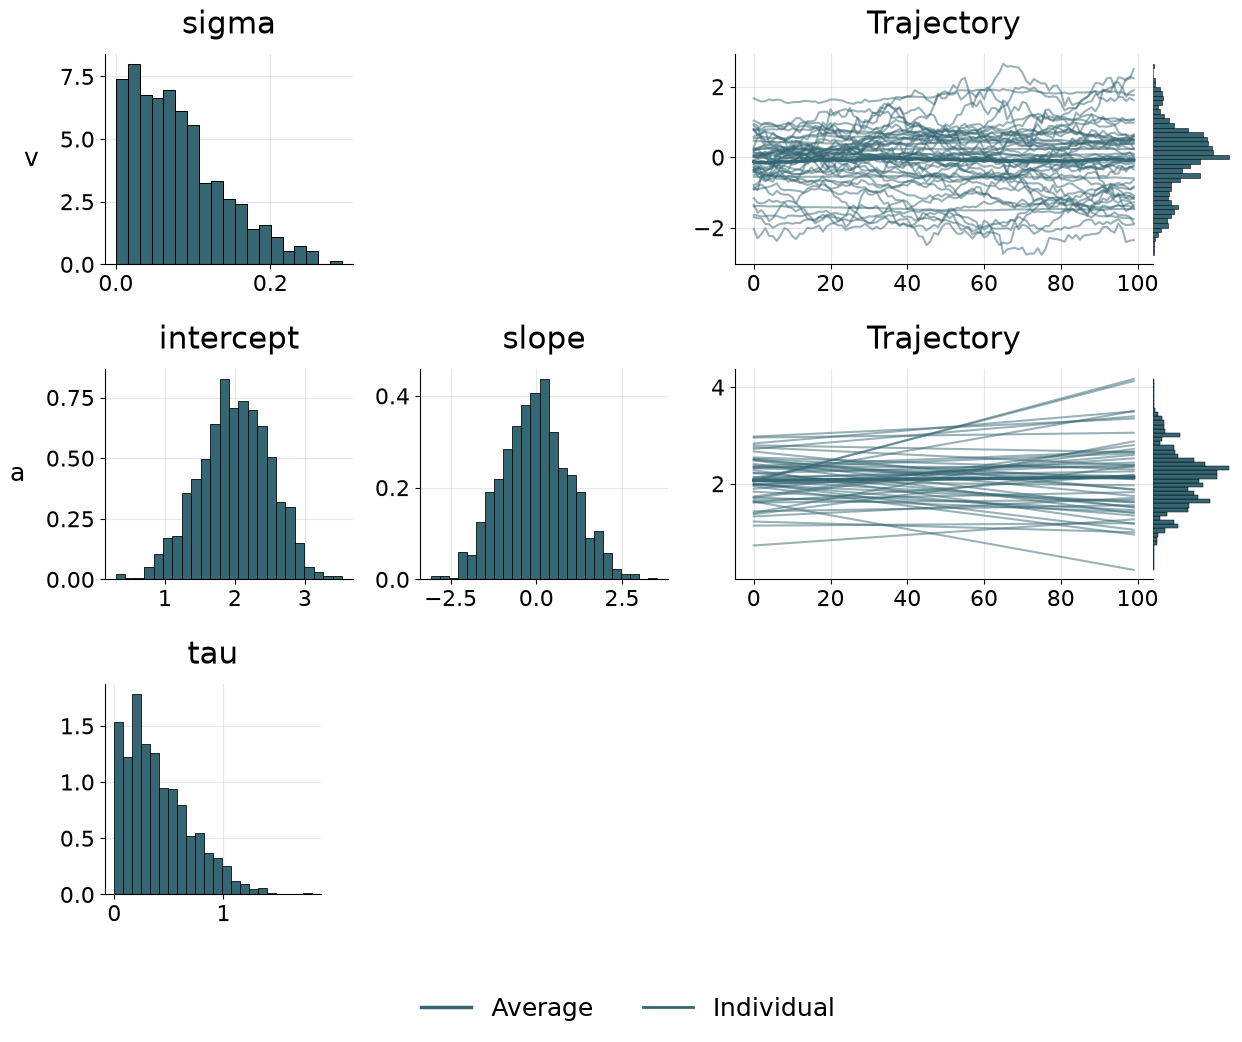

In [6]:
fig = model.plot_joint_prior(
    num_steps=NUM_STEPS,
    num_trajectories=50,
    num_draws=1000,
)

Draw 10 parameter configurations from the joint prior and simulate one dataset of `NUM_STEPS` observations from each.

In [7]:
sim_data = model.sample(batch_size=10, num_steps=NUM_STEPS)

In [8]:
print(
    "Dict keys: ", sim_data.keys(), "\n",
    "Shape of response times: ", sim_data["response_time"].shape, "\n",
    "Shape of a time-varying param: ", sim_data["v"].shape, "\n",
    "Shape of a time-invariant param: ", sim_data["v_sigma"].shape, "\n",
    sep=""
)

Dict keys: dict_keys(['response_time', 'choice', 'time_steps', 'v', 'a', 'v_sigma', 'a_intercept', 'a_slope', 'tau'])
Shape of response times: (10, 100)
Shape of a time-varying param: (10, 100, 1)
Shape of a time-invariant param: (10, 1)



### Prior Push-forward Checks

A prior push-forward check asks whether the complete generative model produces plausible observations before any data are fitted. The call below draws 12 parameter configurations, simulates 12 datasets, and displays the response-time variable (`data_dim=0`) as a distribution (`kind="dist"`). Setting `aggregation=None` keeps one panel per dataset, making between-dataset variation visible. If the plots contain unrealistic response times, choices, or variability, revise the priors or transition assumptions before training.

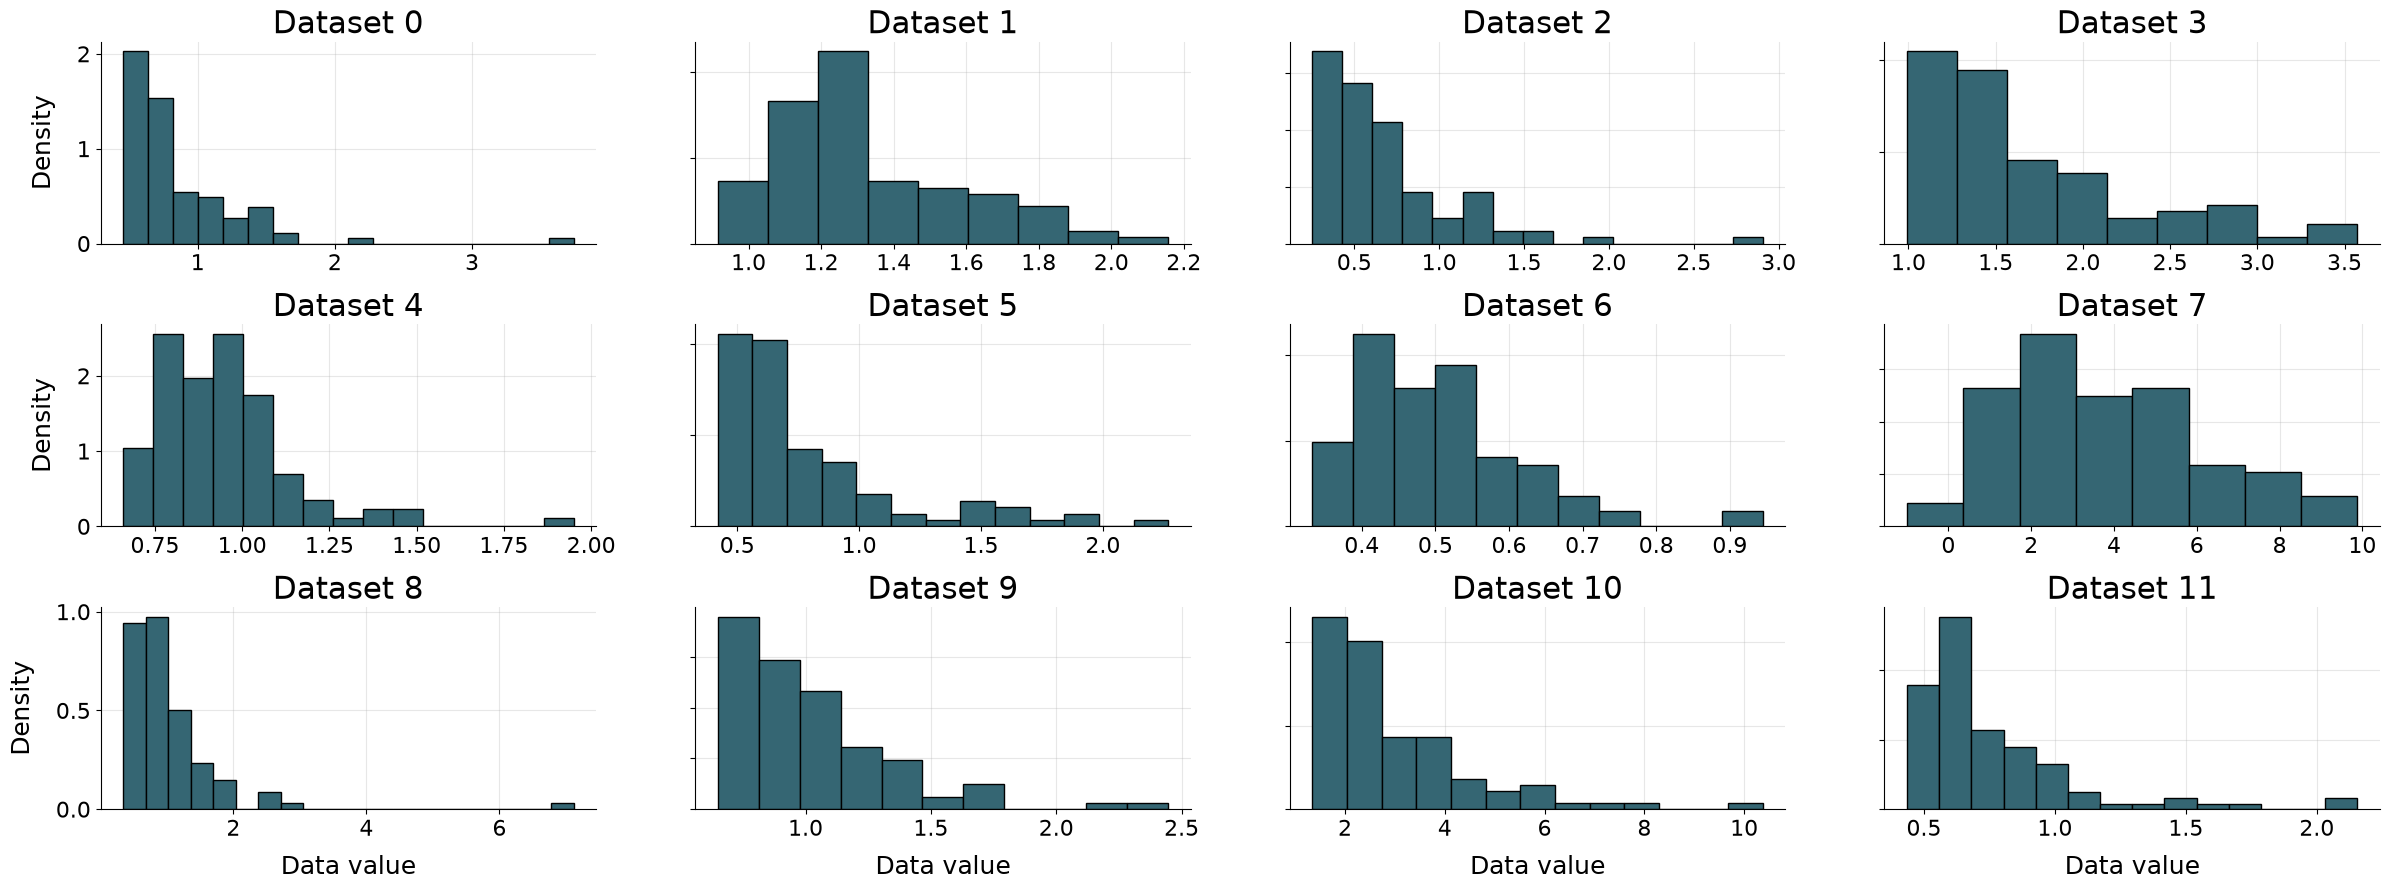

In [9]:
fig = model.plot_push_forward(
    batch_size=12,
    num_steps=NUM_STEPS,
    data_dim=0,
    kind="dist",
    aggregation=None
)

## Setting Up an Amortized Bayesian Workflow

The `Workflow` connects the generative model to a trainable posterior approximator. Here, the string interface explicitly selects marginal smoothing. Superstats supplies its default summary and depth-2 spline inference networks, while BayesFlow supplies its default cosine-decay training schedule.

In [10]:
workflow = sup.Workflow(
    model=model,
    approximator="marginal",
    mode="smoothing",
)

## Amortized Inference

Amortized inference treats posterior estimation as one simulation-based optimization problem. For this DDM demo, each training draw samples `v_sigma`, `a_intercept`, `a_slope`, and $\tau$, rolls out raw $v_{1:T}$ with the random walk, constructs raw $a_{1:T}$ from the linear transition, applies the model-level scaled-sigmoid and clipping links, fixes $z=0.5$, and simulates observations $(\mathrm{RT}_{1:T}, Y_{1:T})$ with `sample_ddm`.

The target is the joint posterior

$$
p\left(v_{1:T}, v_\sigma, a_{\mathrm{intercept}}, a_{\mathrm{slope}}, \tau \mid \mathrm{RT}_{1:T}, Y_{1:T}\right),
$$

The approximator parameters $\phi$ are optimized so the learned conditional density gives high probability to the simulated parameters that generated each simulated dataset:

$$
\phi^\star = \arg\min_\phi \; \mathbb{E}_{\texttt{joint\_prior} + \texttt{sample\_ddm}}\left[-\log q_\phi\left(v_{1:T}, v_\sigma, a_{\mathrm{intercept}}, a_{\mathrm{slope}}, \tau \mid \mathrm{RT}_{1:T}, Y_{1:T}\right)\right].
$$

This upfront simulation and optimization cost is the *amortization* cost. Once paid, posterior samples for many new datasets can be generated quickly. The learned posterior is still an approximation, so principled Bayesian diagnostics remain essential.

### Offline Training

Offline training simulates a fixed dataset once and reuses it across epochs. It is convenient for rapid, reproducible iteration because simulation and training are separated, but the stored data consume memory and limit the diversity of examples seen by the network. Here, `batch_size=20_000` controls the number of simulated training datasets, `epochs=50` controls how often they are revisited, and the optimization `batch_size=32` trades memory use against gradient stability. The smaller held-out validation set monitors generalization; increase it when more stable validation estimates are needed.

In [ ]:
train_data = model.sample(
    batch_size=20_000,
    num_steps=NUM_STEPS
)

val_data = model.sample(
    batch_size=100,
    num_steps=NUM_STEPS
)

Time-varying targets have shape `(batch_size, num_steps, 1)`, while time-invariant targets remain `(batch_size, 1)`. The workflow uses separate inference heads for these two groups, so invariant targets do not need to be tiled along the trial dimension.

The below training takes about 12 minutes on a small GPU. Reduce the simulation budget to 10,000 and the number of training epochs to 30 to drop the training time below 5 minutes.

In [ ]:
history = workflow.fit_offline(
    data=train_data,
    validation_data=val_data,
    epochs=50,
    batch_size=32
)

### Online Training

For fast simulators, you can also use the `.fit_online()` method. Online training generates fresh simulations for every batch, which broadens prior-predictive coverage and avoids storing a large training set. Use it in place of the offline call above when simulation is cheap enough:

```python
history = workflow.fit_online(
    num_steps=NUM_STEPS,
    epochs=50,
    num_batches_per_epoch=1000,
    batch_size=32
)
```

`num_batches_per_epoch`, `epochs`, and `batch_size` set the optimization budget; keep `num_steps` aligned with the sequence length used for inference.

Always inspect the loss curves for signs of overfitting when using offline training:

In [ ]:
fig = workflow.plot_history(workflow.history)

## Model Verification

Simulate 250 held-out datasets for verification. These datasets should not be reused from training: recovery on fresh prior-predictive draws tests whether the amortized posterior generalizes across the assumed parameter space. Larger verification batches give more stable diagnostic summaries but require more simulation and inference time.

In [ ]:
targets = model.sample(batch_size=250, num_steps=NUM_STEPS)

Draw 300 approximate posterior samples for every held-out dataset. Increasing `num_samples` reduces Monte Carlo noise in posterior summaries and diagnostics, at the cost of additional time and memory. The inference `batch_size=4` limits how many datasets are processed together and can be lowered / increased depending on memory constraints.

On suitable hardware, amortized inference for hundreds of synthetic datasets is typically much faster than fitting each dataset separately. Exact runtime depends on the backend, accelerator, batch size, and posterior sample count.

In [ ]:
samples = workflow.sample(data=targets, num_samples=500, batch_size=4)

### Time-Varying Parameters

Plot four diagnostic metrics for the time-varying parameters at every trial:

1. Pearson correlation between the true parameter and posterior median.
2. Normalized root mean squared error (NRMSE) between the true parameter and posterior samples (the Bayesian version).
3. Posterior contraction, which measures how much uncertainty is reduced relative to the prior.
4. Simulation-based calibration error, which assesses whether posterior uncertainty has the correct repeated-simulation coverage.

Inspect the full time profile rather than only its average: poor recovery at particular trials can reveal boundary effects, weak information, or fluctuations that are too rapid for the chosen transition model and network to resolve.

In [ ]:
fig = workflow.verify_time_varying(targets=targets, estimates=samples)

### Why the (Inverted) U-Shape Recovery?

Recovery often looks inverted U-shaped (for NRMSE or posterior contraction) or U-shaped (for correlation) because the estimator learns the **smoothing posterior**, not a filtering posterior. That is, inference for each trial’s latent parameter uses information from the full observed sequence, including both past and future trials. 

For parameters near the middle of the sequence, evidence is available from both sides, so the trajectory is better constrained. Near the beginning and end, information is available only from one side, and the influence of observations decays with distance. As a result, posterior uncertainty is larger and recovery is weaker at the boundaries, producing the typical inverted U-shaped recovery profile across trials.

### Time-Invariant Parameters

For time-invariant parameters, inspect parameter recovery, simulation-based calibration, and posterior z-scores together with contraction. Recovery measures point-estimate accuracy, calibration tests uncertainty, and contraction indicates how informative the data are relative to the prior; no single diagnostic is sufficient on its own.

In [ ]:
from scipy.stats import median_abs_deviation


fig_recovery, fig_calibration, fig_z_score_contraction = workflow.verify_time_invariant(
    estimates=samples,
    targets=targets,
    uncertainty_agg=median_abs_deviation
)

## Fitting Real Data

To fit empirical data, preserve trial order and format the observations exactly like the simulator output—for this DDM, named response-time and choice arrays with the expected batch and trial dimensions. `workflow.prepare_data()` can help adapt the arrays before they are passed to `workflow.sample()`. 

The empirical sequence length, coding of choices, missing-value handling, and preprocessing must agree with the choices used during training. For this self-contained demonstration, the cell below uses newly simulated data as a placeholder for 12 participants.

In [ ]:
num_subjects = 12

data = model.sample(batch_size=num_subjects, num_steps=NUM_STEPS)

samples = workflow.sample(data=data, num_samples=500, batch_size=4)

## Posterior Re-simulations

Posterior re-simulation is a posterior-predictive check: draw parameters from each fitted posterior, simulate new datasets, and compare those predictions with the fitted data. Agreement in response-time distributions, choice proportions, and temporal patterns indicates that the fitted model can reproduce important features of the observations; systematic discrepancies point to model misspecification. `num_sims=100` requests 100 replicated trajectories for each dataset. Increase it for more stable predictive summaries.

In [ ]:
resim_data = workflow.resimulate(samples, num_sims=100)

In [ ]:
fig = sup.diagnostics.plot_posterior_resimulation(prediction=resim_data, empirical=data)

## Posterior Estimates

### Time-Varying Parameters

Plot the posterior trajectories for the non-stationary parameters. The median (`aggregation=np.median`) provides a compact trajectory estimate, while the spread of posterior draws should be retained when judging whether apparent fluctuations are credibly different from uncertainty.

In [ ]:
fig = workflow.plot_time_varying_posterior(
    estimates=samples,
    targets=data,
    aggregation=np.median,
)

### Time-Invariant Parameters

Plot marginal posteriors for shared parameters and transition hyperparameters. Select one participant with `data_idx`, as below, or omit it to include every fitted dataset.

In [ ]:
fig = workflow.plot_marginals(
    estimates=samples,
    targets=data,
    data_idx=0
)

Alternatively, we can also use a pairs plot to inspect bivariat posteriors.

In [ ]:
fig = workflow.plot_pairs(
    estimates=samples,
    targets=data,
    data_idx=0
)

For inspection of the time-invariant posteriors on an aggreagte level, we can use `plot_forest()`

In [ ]:
fig = workflow.plot_forest(
    estimates=samples,
    targets=data,
    aggregation=np.median
)